# CẤU HÌNH

In [ ]:
import os, random, unicodedata, re, json, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'DejaVu Sans'
from PIL import Image, ImageFilter
from collections import Counter
from tqdm import tqdm
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')
DATA_DIR   = r"C:\Users\thai\Documents\VnOnDB"
OUTPUT_DIR = r"C:\Users\thai\Documents\VnOnDB_output"
os.makedirs(OUTPUT_DIR, exist_ok=True)
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# THĂM DÒ DỮ LIỆU

## 1. KIỂM TRA SỐ LƯỢNG FILE & CẶP

In [ ]:
all_files = os.listdir(DATA_DIR)
png_set   = {f[:-4] for f in all_files if f.endswith('.png')}
txt_set   = {f[:-4] for f in all_files if f.endswith('.txt')}
paired    = png_set & txt_set
png_only  = png_set - txt_set
txt_only  = txt_set - png_set

print(f"  Tổng file .png       : {len(png_set):,}")
print(f"  Tổng file .txt       : {len(txt_set):,}")
print(f"  Cặp đầy đủ (png+txt) : {len(paired):,}")
print(f"  PNG không có TXT     : {len(png_only):,}  {'CẦN XỬ LÝ' if png_only else 'OK'}")
print(f"  TXT không có PNG     : {len(txt_only):,}  {'CẦN XỬ LÝ' if txt_only else 'OK'}")

paired_list = sorted(paired)

  Tổng file .png       : 110,746
  Tổng file .txt       : 110,746
  Cặp đầy đủ (png+txt) : 110,746
  PNG không có TXT     : 0  OK
  TXT không có PNG     : 0  OK


## 2. KIỂM TRA NHÃN TOÀN BỘ

In [ ]:
all_labels    = {}
empty_labels  = []
encode_errors = []
bad_char_labels = []

def has_bad_chars(text):
    return bool(re.search(r'[\x00-\x08\x0b\x0c\x0e-\x1f\x7f]', text))

for name in tqdm(paired_list, desc="  Đọc nhãn"):
    try:
        with open(os.path.join(DATA_DIR, name + '.txt'), 'r', encoding='utf-8') as f:
            lbl = f.read().strip()
        all_labels[name] = lbl
        if not lbl:
            empty_labels.append(name)
        elif has_bad_chars(lbl):
            bad_char_labels.append((name, lbl))
    except:
        try:
            with open(os.path.join(DATA_DIR, name + '.txt'), 'r', encoding='utf-8-sig') as f:
                lbl = f.read().strip()
            all_labels[name] = lbl
        except:
            encode_errors.append(name)

labels_list = list(all_labels.values())
label_lens  = [len(l) for l in labels_list]

nfc_diff = sum(1 for l in labels_list if unicodedata.normalize('NFC', l) != l)

print(f"\n  Tổng nhãn đọc được   : {len(all_labels):,}")
print(f"  Lỗi encoding         : {len(encode_errors):,}  {'LỖI' if encode_errors else 'OK'}")
print(f"  Nhãn rỗng            : {len(empty_labels):,}   {'CẦN XỬ LÝ' if empty_labels else 'OK'}")
print(f"  Nhãn có ký tự xấu   : {len(bad_char_labels):,}  {'CẦN XỬ LÝ' if bad_char_labels else 'OK'}")
print(f"  Nhãn chưa NFC        : {nfc_diff:,}  {'CẦN CHUẨN HÓA' if nfc_diff else 'OK'}")

if bad_char_labels:
    print(f"  Ví dụ nhãn xấu:")
    for name, lbl in bad_char_labels[:5]:
        print(f"    {name}: {repr(lbl)}")

print(f"\n  Độ dài nhãn:")
print(f"    TB       : {np.mean(label_lens):.2f} ký tự")
print(f"    Ngắn nhất: {min(label_lens)} ký tự => \"{min(all_labels.values(), key=len)}\"")
print(f"    Dài nhất : {max(label_lens)} ký tự => \"{max(all_labels.values(), key=len)}\"")
print(f"    P50      : {np.percentile(label_lens, 50):.0f} ký tự")
print(f"    P95      : {np.percentile(label_lens, 95):.0f} ký tự")
print(f"    P99      : {np.percentile(label_lens, 99):.0f} ký tự")
print(f"  Số từ unique         : {len(set(labels_list)):,}")

all_chars_cnt = Counter(''.join(labels_list))
sorted_chars  = sorted(all_chars_cnt.keys())
print(f"\n  Số ký tự unique      : {len(all_chars_cnt)}")
print(f"  Bộ ký tự             : {' '.join(sorted_chars)}")

rare_chars = {c: n for c, n in all_chars_cnt.items() if n < 50}
print(f"\n  Ký tự hiếm < 50 lần : {len(rare_chars)} ký tự")
for c, n in sorted(rare_chars.items(), key=lambda x: x[1]):
    cat    = unicodedata.category(c)
    name_c = unicodedata.name(c, 'unknown')
    print(f"    '{c}' (U+{ord(c):04X} | {cat} | {name_c}): {n} lần")

  Đọc nhãn: 100%|██████████| 110746/110746 [02:00<00:00, 917.23it/s] 



  Tổng nhãn đọc được   : 110,746
  Lỗi encoding         : 0  OK
  Nhãn rỗng            : 0   OK
  Nhãn có ký tự xấu   : 0  OK
  Nhãn chưa NFC        : 0  OK

  Độ dài nhãn:
    TB       : 3.33 ký tự
    Ngắn nhất: 1 ký tự => "8"
    Dài nhất : 11 ký tự => "Environment"
    P50      : 3 ký tự
    P95      : 5 ký tự
    P99      : 6 ký tự
  Số từ unique         : 3,511

  Số ký tự unique      : 147
  Bộ ký tự             : 0 1 2 3 4 5 6 7 8 9 A B C D E F G H I J K L M N O P Q R S T U V W X Y a b c d e f g h i j k l m n o p q r s t u v x y z À Á Â Ô Ú Ý à á â ã è é ê ì í ò ó ô õ ù ú ý Ă ă Đ đ ĩ ũ ƒ Ơ ơ Ư ư ạ Ả ả Ấ ấ Ầ ầ ẩ ẫ ậ ắ ằ ẳ ẵ ặ ẹ ẻ ẽ ế Ề ề Ể ể ễ Ệ ệ ỉ ị ọ ỏ Ố ố Ồ ồ ổ ỗ ộ ớ ờ Ở ở ỡ ợ ụ Ủ ủ ứ ừ ử ữ ự ỳ ỷ ỹ

  Ký tự hiếm < 50 lần : 27 ký tự
    'F' (U+0046 | Lu | LATIN CAPITAL LETTER F): 1 lần
    'Ầ' (U+1EA6 | Lu | LATIN CAPITAL LETTER A WITH CIRCUMFLEX AND GRAVE): 1 lần
    'Ố' (U+1ED0 | Lu | LATIN CAPITAL LETTER O WITH CIRCUMFLEX AND ACUTE): 1 lần
    'Ý' (U+00DD | Lu | LATIN CAP

## 3. KIỂM TRA TOÀN BỘ ẢNH (kích thước + mode + chất lượng)

In [ ]:
widths, heights, ratios, modes_list = [], [], [], []
brightness_list, contrast_list, sharpness_list = [], [], []
broken_images = []
rgba_images   = []

for name in tqdm(paired_list, desc="  Kiểm tra ảnh"):
    path = os.path.join(DATA_DIR, name + '.png')
    try:
        img = Image.open(path)
        w, h = img.size
        widths.append(w)
        heights.append(h)
        ratios.append(w / h)
        modes_list.append(img.mode)
        if img.mode == 'RGBA':
            rgba_images.append(name)

        gray = img.convert('L')
        arr  = np.array(gray, dtype=np.float32)
        brightness_list.append(arr.mean())
        contrast_list.append(arr.std())
        lap = gray.filter(ImageFilter.FIND_EDGES)
        sharpness_list.append(np.array(lap, dtype=np.float32).var())
    except:
        broken_images.append(name)

print(f"\n  Tổng ảnh kiểm tra    : {len(widths):,}")
print(f"  Ảnh hỏng (lỗi mở)   : {len(broken_images):,}  {'CẦN XỬ LÝ' if broken_images else 'OK'}")
print(f"  Ảnh RGBA (có alpha)  : {len(rgba_images):,}  {'=> convert RGB khi load' if rgba_images else 'OK'}")

print(f"\n  Kích thước:")
print(f"    Width  - TB:{np.mean(widths):.0f}  Min:{min(widths)}  Max:{max(widths)}  P5:{np.percentile(widths,5):.0f}  P95:{np.percentile(widths,95):.0f}")
print(f"    Height - TB:{np.mean(heights):.0f}  Min:{min(heights)}  Max:{max(heights)}  P5:{np.percentile(heights,5):.0f}  P95:{np.percentile(heights,95):.0f}")
print(f"    Aspect ratio - TB:{np.mean(ratios):.2f}  Min:{min(ratios):.2f}  Max:{max(ratios):.2f}")
print(f"    Mode ảnh: {Counter(modes_list).most_common()}")

print(f"\n  Chất lượng:")
print(f"    Brightness - TB:{np.mean(brightness_list):.1f}  Min:{np.min(brightness_list):.1f}  Max:{np.max(brightness_list):.1f}")
print(f"    Contrast   - TB:{np.mean(contrast_list):.1f}  Min:{np.min(contrast_list):.1f}  Max:{np.max(contrast_list):.1f}")
print(f"    Sharpness  - TB:{np.mean(sharpness_list):.1f}  Min:{np.min(sharpness_list):.1f}  Max:{np.max(sharpness_list):.1f}")

low_contrast = sum(1 for c in contrast_list if c < 10)
print(f"\n  Ảnh contrast thấp (std < 10): {low_contrast:,}  {'CẦN LOẠI' if low_contrast else 'OK'}")

  Kiểm tra ảnh: 100%|██████████| 110746/110746 [06:28<00:00, 284.90it/s]



  Tổng ảnh kiểm tra    : 110,746
  Ảnh hỏng (lỗi mở)   : 0  OK
  Ảnh RGBA (có alpha)  : 110,746  => convert RGB khi load

  Kích thước:
    Width  - TB:480  Min:68  Max:523  P5:316  P95:523
    Height - TB:341  Min:96  Max:396  P5:219  P95:396
    Aspect ratio - TB:1.49  Min:0.17  Max:5.45
    Mode ảnh: [('RGBA', 110746)]

  Chất lượng:
    Brightness - TB:253.4  Min:251.0  Max:255.0
    Contrast   - TB:14.9  Min:0.0  Max:23.6
    Sharpness  - TB:1730.1  Min:924.3  Max:3981.7

  Ảnh contrast thấp (std < 10): 107  CẦN LOẠI


##4. BIỂU ĐỒ CHẤT LƯỢNG ẢNH

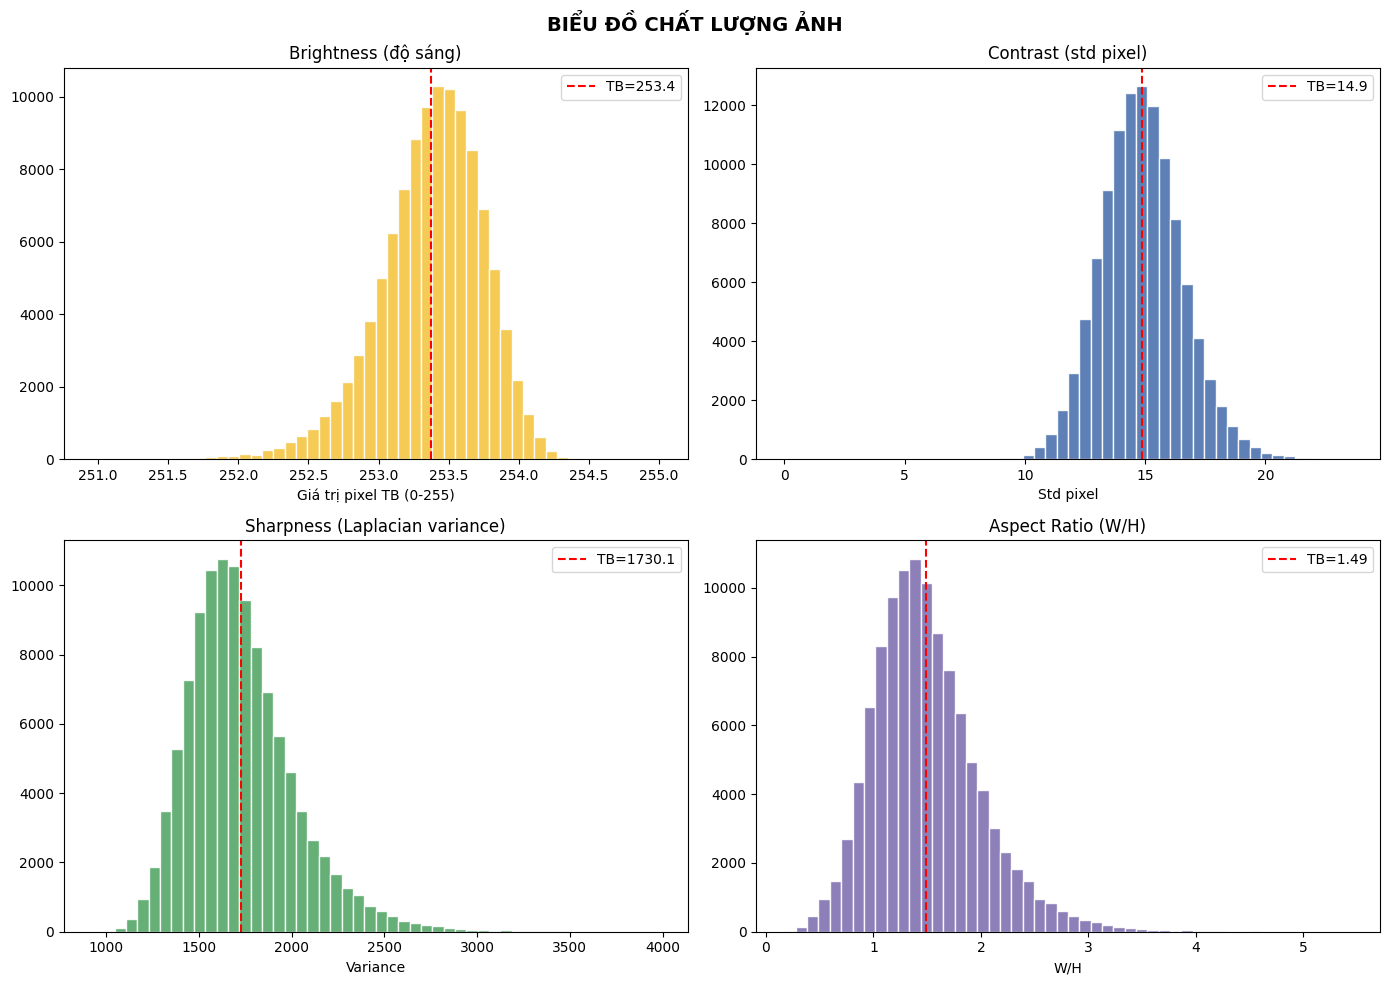

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('BIỂU ĐỒ CHẤT LƯỢNG ẢNH', fontsize=14, fontweight='bold')

axes[0,0].hist(brightness_list, bins=50, color='#F4C542', edgecolor='white', alpha=0.9)
axes[0,0].axvline(np.mean(brightness_list), color='red', linestyle='--', label=f'TB={np.mean(brightness_list):.1f}')
axes[0,0].set_title('Brightness (độ sáng)')
axes[0,0].set_xlabel('Giá trị pixel TB (0-255)')
axes[0,0].legend()

axes[0,1].hist(contrast_list, bins=50, color='#4C72B0', edgecolor='white', alpha=0.9)
axes[0,1].axvline(np.mean(contrast_list), color='red', linestyle='--', label=f'TB={np.mean(contrast_list):.1f}')
axes[0,1].set_title('Contrast (std pixel)')
axes[0,1].set_xlabel('Std pixel')
axes[0,1].legend()

axes[1,0].hist(sharpness_list, bins=50, color='#55A868', edgecolor='white', alpha=0.9)
axes[1,0].axvline(np.mean(sharpness_list), color='red', linestyle='--', label=f'TB={np.mean(sharpness_list):.1f}')
axes[1,0].set_title('Sharpness (Laplacian variance)')
axes[1,0].set_xlabel('Variance')
axes[1,0].legend()

axes[1,1].hist(ratios, bins=50, color='#8172B2', edgecolor='white', alpha=0.9)
axes[1,1].axvline(np.mean(ratios), color='red', linestyle='--', label=f'TB={np.mean(ratios):.2f}')
axes[1,1].set_title('Aspect Ratio (W/H)')
axes[1,1].set_xlabel('W/H')
axes[1,1].legend()

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'image_quality.png'), dpi=130, bbox_inches='tight')
plt.show()

# 5. LÀM SẠCH + CHUẨN HÓA NFC

In [ ]:
removed = {'broken_image': [], 'low_contrast': []}
clean_names  = []
clean_labels = {}
nfc_changed  = 0

for name in tqdm(paired_list, desc="  Làm sạch"):
    try:
        img = Image.open(os.path.join(DATA_DIR, name + '.png')).convert('L')
        arr = np.array(img, dtype=np.float32)
        if arr.std() < 10:
            removed['low_contrast'].append(name)
            continue
    except:
        removed['broken_image'].append(name)
        continue

    lbl     = all_labels[name].strip()
    nfc_lbl = unicodedata.normalize('NFC', lbl)
    if nfc_lbl != lbl:
        nfc_changed += 1
    clean_labels[name] = nfc_lbl
    clean_names.append(name)

total_removed = sum(len(v) for v in removed.values())

print(f"\n  Kết quả:")
for reason, names in removed.items():
    if names:
        print(f"    {reason}: {len(names):,}")
print(f"  Tổng bị loại   : {total_removed:,}")
print(f"  Còn lại (sạch)  : {len(clean_names):,}")
print(f"  Tỉ lệ giữ lại  : {len(clean_names)/len(paired_list)*100:.2f}%")
print(f"  Nhãn thay đổi NFC: {nfc_changed}")

removed_log = [
    {'filename': n + '.png', 'reason': reason, 'label': all_labels.get(n, '')}
    for reason, names in removed.items() for n in names
]
if removed_log:
    pd.DataFrame(removed_log).to_csv(
        os.path.join(OUTPUT_DIR, 'removed_samples.csv'),
        index=False, encoding='utf-8-sig')
    print(f"  Đã lưu: removed_samples.csv ({len(removed_log)} dòng)")

  Làm sạch: 100%|██████████| 110746/110746 [05:07<00:00, 360.07it/s]


  Kết quả:
    low_contrast: 107
  Tổng bị loại   : 107
  Còn lại (sạch)  : 110,639
  Tỉ lệ giữ lại  : 99.90%
  Nhãn thay đổi NFC: 0
  Đã lưu: removed_samples.csv (107 dòng)


# 6. CHIA DỮ LIỆU - STRATIFIED SAMPLING 80/10/10

In [ ]:
strat_labels = [min(len(clean_labels[n]), 7) for n in clean_names]

train_names, temp_names, train_strat, temp_strat = train_test_split(
    clean_names, strat_labels,
    test_size=0.20, random_state=SEED, stratify=strat_labels
)

val_names, test_names = train_test_split(
    temp_names,
    test_size=0.50, random_state=SEED, stratify=temp_strat
)

print(f"  Tổng mẫu sạch   : {len(clean_names):,}")
print(f"  Train (80%)      : {len(train_names):,}")
print(f"  Validation (10%) : {len(val_names):,}")
print(f"  Test (10%)       : {len(test_names):,}")

def label_len_dist(names):
    return Counter([len(clean_labels[n]) for n in names])

print(f"\n  Phân phối độ dài nhãn:")
print(f"  {'Tập':<12} {'TB':>6}  {'1c':>6}  {'2c':>6}  {'3c':>6}  {'4c':>6}  {'5c':>6}  {'6c':>6}  {'7c+':>6}")
for sname, names in [('Train', train_names), ('Val', val_names), ('Test', test_names)]:
    dist = label_len_dist(names)
    n    = len(names)
    avg  = np.mean([len(clean_labels[nm]) for nm in names])
    print(f"  {sname:<12} {avg:>6.3f}  "
          f"{dist.get(1,0)/n*100:>5.1f}%  "
          f"{dist.get(2,0)/n*100:>5.1f}%  "
          f"{dist.get(3,0)/n*100:>5.1f}%  "
          f"{dist.get(4,0)/n*100:>5.1f}%  "
          f"{dist.get(5,0)/n*100:>5.1f}%  "
          f"{dist.get(6,0)/n*100:>5.1f}%  "
          f"{sum(dist.get(k,0) for k in range(7,20))/n*100:>5.1f}%")

train_set = set(train_names)
val_set   = set(val_names)
test_set  = set(test_names)
print(f"\n  Data leakage:")
print(f"    Train giao Val  : {len(train_set & val_set)}  {'OK' if not (train_set & val_set) else 'LỖI!'}")
print(f"    Train giao Test : {len(train_set & test_set)}  {'OK' if not (train_set & test_set) else 'LỖI!'}")
print(f"    Val   giao Test : {len(val_set & test_set)}  {'OK' if not (val_set & test_set) else 'LỖI!'}")

  Tổng mẫu sạch   : 110,639
  Train (80%)      : 88,511
  Validation (10%) : 11,064
  Test (10%)       : 11,064

  Phân phối độ dài nhãn:
  Tập              TB      1c      2c      3c      4c      5c      6c     7c+
  Train         3.328    1.8%   19.8%   38.0%   27.0%   11.5%    1.9%    0.1%
  Val           3.328    1.8%   19.8%   38.0%   27.0%   11.5%    1.9%    0.1%
  Test          3.328    1.8%   19.8%   38.0%   27.0%   11.5%    1.9%    0.1%

  Data leakage:
    Train giao Val  : 0  OK
    Train giao Test : 0  OK
    Val   giao Test : 0  OK


# 7. LƯU CSV + CONFIG

In [ ]:
def make_df(names):
    return pd.DataFrame({
        'filename': [n + '.png' for n in names],
        'label':    [clean_labels[n] for n in names]
    })

df_train = make_df(train_names)
df_val   = make_df(val_names)
df_test  = make_df(test_names)

df_train.to_csv(os.path.join(OUTPUT_DIR, 'train.csv'), index=False, encoding='utf-8-sig')
df_val.to_csv(os.path.join(OUTPUT_DIR, 'val.csv'),     index=False, encoding='utf-8-sig')
df_test.to_csv(os.path.join(OUTPUT_DIR, 'test.csv'),   index=False, encoding='utf-8-sig')

clean_chars = Counter(''.join(clean_labels.values()))

config = {
    'total_original'   : len(paired_list),
    'total_removed'    : total_removed,
    'total_clean'      : len(clean_names),
    'train'            : len(train_names),
    'val'              : len(val_names),
    'test'             : len(test_names),
    'split_ratio'      : '80/10/10',
    'split_method'     : 'stratified by label length',
    'seed'             : SEED,
    'num_unique_chars' : len(clean_chars),
    'charset'          : sorted(clean_chars.keys()),
    'unicode_normalize': 'NFC',
    'image_mode'       : 'RGBA => convert RGB khi load',
    'resize'           : 'TrOCRProcessor tự xử lý 384x384',
    'csv_note'         : 'filename chỉ là tên file, ghép với data_dir khi load',
}
with open(os.path.join(OUTPUT_DIR, 'dataset_config.json'), 'w', encoding='utf-8') as f:
    json.dump(config, f, ensure_ascii=False, indent=2)

print(f"  Đã lưu vào {OUTPUT_DIR}:")
print(f"    train.csv            ({len(df_train):,} dòng)")
print(f"    val.csv              ({len(df_val):,} dòng)")
print(f"    test.csv             ({len(df_test):,} dòng)")
print(f"    removed_samples.csv  ({len(removed_log):,} dòng)")
print(f"    dataset_config.json")
print(f"    image_quality.png")

print(f"\n  Xem thử 5 dòng train.csv:")
print(df_train.head().to_string(index=False))

  Đã lưu vào C:\Users\thai\Documents\VnOnDB_output:
    train.csv            (88,511 dòng)
    val.csv              (11,064 dòng)
    test.csv             (11,064 dòng)
    removed_samples.csv  (107 dòng)
    dataset_config.json
    image_quality.png

  Xem thử 5 dòng train.csv:
                          filename label
20160722_0201_26749_2_tg_1_3_4.png  nhất
20140922_0027_5770_2_tg_1_0_11.png  cuộc
20151209_0144_7398_2_tg_1_3_12.png   kịp
20160504_0112_25849_2_tg_3_7_3.png  trạm
20140603_0023_KQBDVN_tg_0_1_16.png  biển


# CẤU HÌNH TRAIN

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
!pip install -q transformers evaluate albumentations jiwer tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 97.2 MB/s eta 0:00:00


In [ ]:
import os, gc, json, zipfile, shutil, torch
import random
import numpy as np
import pandas as pd
from PIL import Image
from pathlib import Path
import matplotlib.pyplot as plt
from jiwer import wer
from collections import Counter
from tqdm import tqdm
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import cv2
import albumentations as A
from torch.optim import AdamW
from transformers import (
    TrOCRProcessor,
    VisionEncoderDecoderModel,
    GenerationConfig,
    get_linear_schedule_with_warmup,
)
import evaluate as hf_evaluate
import albumentations as A
import warnings
warnings.filterwarnings('ignore')

DRIVE_BASE = '/content/drive/MyDrive/Colab Notebooks'
DATA_DIR   = '/content/VnOnDB/InkData_word_processed'
OUTPUT_DIR = '/content/VnOnDB_output'
SAVE_DIR   = os.path.join(DRIVE_BASE, 'trocr_checkpoints')
os.makedirs(SAVE_DIR, exist_ok=True)

# GIẢI NÉN + ĐỊNH NGHĨA DATASET

In [ ]:
MODEL_NAME = 'microsoft/trocr-base-handwritten'

if not os.path.exists(DATA_DIR):
    print('Giải nén ảnh...')
    os.makedirs('/content/VnOnDB', exist_ok=True)
    with zipfile.ZipFile(os.path.join(DRIVE_BASE, 'VnOnDB.zip'), 'r') as zf:
        for member in tqdm(zf.namelist(), desc='Extracting'):
            zf.extract(member, '/content/VnOnDB')
    print(f' {len(os.listdir(DATA_DIR)):,} files')
else:
    print(f' Ảnh đã có: {len(os.listdir(DATA_DIR)):,} files')

if not os.path.exists(OUTPUT_DIR):
    shutil.copytree(os.path.join(DRIVE_BASE, 'VnOnDB_output'), OUTPUT_DIR)
    print(' Copied CSV')
else:
    print(' CSV đã có')

print('\nLoad processor...')
processor = TrOCRProcessor.from_pretrained(MODEL_NAME)

print('\nCheck max_target_length...')
all_labels_list = []
for csv_name in ['train.csv', 'val.csv', 'test.csv']:
    df_tmp = pd.read_csv(os.path.join(OUTPUT_DIR, csv_name))
    all_labels_list.extend(df_tmp['label'].astype(str).tolist())

token_lens = [len(processor.tokenizer(l, add_special_tokens=True).input_ids)
              for l in all_labels_list]
max_tok = max(token_lens)
MAX_TARGET_LENGTH = max_tok + 4
print(f'  Token max: {max_tok} => MAX_TARGET_LENGTH = {MAX_TARGET_LENGTH} (max + buffer 4)')

_train_aug = A.Compose([
    A.ElasticTransform(
        alpha=20, sigma=4, alpha_affine=4,
        border_mode=cv2.BORDER_CONSTANT, value=255, p=0.35),
    A.ShiftScaleRotate(
        shift_limit=0.02, scale_limit=0.05, rotate_limit=6,
        border_mode=cv2.BORDER_CONSTANT, value=255, p=0.40),
    A.GaussNoise(var_limit=(5, 25), p=0.30),
    A.GaussianBlur(blur_limit=(3, 3), p=0.25),
    A.RandomBrightnessContrast(
        brightness_limit=0.10, contrast_limit=0.15, p=0.40),
])

class VNOnDBDataset(Dataset):
    def __init__(self, csv_path, data_dir, processor,
                 max_target_length=32, augment=False):
        self.df        = pd.read_csv(csv_path)
        self.data_dir  = Path(data_dir)
        self.processor = processor
        self.max_len   = max_target_length
        self.augment   = augment
        print(f'  Loaded {len(self.df):,} samples từ {Path(csv_path).name}'
              f'  [aug={"ON" if augment else "OFF"}]')

    def __len__(self): return len(self.df)

    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        image = Image.open(self.data_dir / row['filename']).convert('RGB')
        if self.augment:
            img_np = np.array(image)
            img_np = _train_aug(image=img_np)['image']
            image  = Image.fromarray(img_np)
        pv  = self.processor(image, return_tensors='pt').pixel_values.squeeze(0)
        ids = self.processor.tokenizer(
            str(row['label']), padding='max_length',
            max_length=self.max_len, truncation=True,
        ).input_ids
        ids = [i if i != self.processor.tokenizer.pad_token_id else -100
               for i in ids]
        return {'pixel_values': pv,
                'labels'      : torch.tensor(ids, dtype=torch.long)}

train_dataset = VNOnDBDataset(os.path.join(OUTPUT_DIR, 'train.csv'),
                               DATA_DIR, processor, MAX_TARGET_LENGTH,
                               augment=True)
val_dataset   = VNOnDBDataset(os.path.join(OUTPUT_DIR, 'val.csv'),
                               DATA_DIR, processor, MAX_TARGET_LENGTH,
                               augment=False)
test_dataset  = VNOnDBDataset(os.path.join(OUTPUT_DIR, 'test.csv'),
                               DATA_DIR, processor, MAX_TARGET_LENGTH,
                               augment=False)

print(f'\nSẵn sàng Train={len(train_dataset):,} | Val={len(val_dataset):,} | Test={len(test_dataset):,}')

 Ảnh đã có: 221,492 files
 CSV đã có

Load processor...

Check max_target_length...
  Token max: 10 => MAX_TARGET_LENGTH = 14 (max + buffer 4)
  Loaded 88,511 samples từ train.csv  [aug=ON]
  Loaded 11,064 samples từ val.csv  [aug=OFF]
  Loaded 11,064 samples từ test.csv  [aug=OFF]

Sẵn sàng Train=88,511 | Val=11,064 | Test=11,064


# TRAIN

In [ ]:
CFG = {
    'model_name'      : 'microsoft/trocr-base-handwritten',
    'num_epochs'      : 10,
    'batch_size'      : 64,
    'grad_accum_steps': 1,
    'learning_rate'   : 2e-5,
    'weight_decay'    : 0.01,
    'warmup_steps'    : 500,
    'max_grad_norm'   : 1.0,
    'fp16'            : True,
    'num_workers'     : 4,
    'num_beams'       : 1,
    'gen_max_length'  : 32,
    'no_repeat_ngram' : 3,
    'length_penalty'  : 1.0,
    'save_dir'        : SAVE_DIR,
    'patience'        : 3,
    'tone_alpha'      : 2.0,
}

cer_metric = hf_evaluate.load('cer')

def validate(model, loader, device, cfg):
    model.eval()
    all_preds, all_labels = [], []
    gen_cfg = GenerationConfig(
        max_new_tokens         = cfg['gen_max_length'],
        num_beams              = cfg['num_beams'],
        no_repeat_ngram_size   = cfg['no_repeat_ngram'],
        length_penalty         = cfg['length_penalty'],
        early_stopping         = True,
        decoder_start_token_id = processor.tokenizer.cls_token_id,
        eos_token_id           = processor.tokenizer.sep_token_id,
        pad_token_id           = processor.tokenizer.pad_token_id,
    )
    with torch.no_grad():
        for batch in tqdm(loader, desc='  Validating', leave=False):
            pv  = batch['pixel_values'].to(device)
            lbl = batch['labels'].to(device)
            ids = model.generate(pv, generation_config=gen_cfg)
            pred_str  = processor.batch_decode(ids, skip_special_tokens=True)
            lbl[lbl == -100] = processor.tokenizer.pad_token_id
            label_str = processor.batch_decode(lbl, skip_special_tokens=True)
            all_preds.extend(pred_str)
            all_labels.extend(label_str)
    model.train()
    return cer_metric.compute(predictions=all_preds, references=all_labels)

def save_checkpoint(model, optimizer, scheduler, scaler,
                    epoch, best_cer, patience_count, history, cfg):
    ckpt_dir = os.path.join(cfg['save_dir'], f'epoch_{epoch:02d}')
    os.makedirs(ckpt_dir, exist_ok=True)
    model.save_pretrained(ckpt_dir)
    processor.save_pretrained(ckpt_dir)
    torch.save({
        'epoch'         : epoch,
        'best_cer'      : best_cer,
        'patience_count': patience_count,
        'history'       : history,
        'optimizer'     : optimizer.state_dict(),
        'scheduler'     : scheduler.state_dict(),
        'scaler'        : scaler.state_dict(),
    }, os.path.join(ckpt_dir, 'training_state.pt'))
    with open(os.path.join(cfg['save_dir'], 'latest_epoch.txt'), 'w') as f:
        f.write(str(epoch))
    print(f'   Saved => epoch_{epoch:02d}/')

def find_latest_checkpoint(cfg):
    f = os.path.join(cfg['save_dir'], 'latest_epoch.txt')
    if not os.path.exists(f): return None
    epoch    = int(open(f).read().strip())
    ckpt_dir = os.path.join(cfg['save_dir'], f'epoch_{epoch:02d}')
    if os.path.exists(os.path.join(ckpt_dir, 'training_state.pt')):
        return ckpt_dir, epoch
    return None

def load_checkpoint(ckpt_dir, device):
    print(f'   Loading: {ckpt_dir}')
    m     = VisionEncoderDecoderModel.from_pretrained(ckpt_dir).to(device)
    state = torch.load(os.path.join(ckpt_dir, 'training_state.pt'),
                       map_location=device, weights_only=False)
    return m, state

def main():
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f'Device : {device}  |  GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM   : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB\n')

    resume_info = find_latest_checkpoint(CFG)

    if resume_info:
        ckpt_dir, last_epoch = resume_info
        print(f'Resume từ epoch {last_epoch}!')
        model, state = load_checkpoint(ckpt_dir, device)
        start_epoch    = last_epoch + 1
        best_cer       = state['best_cer']
        patience_count = state['patience_count']
        history        = state['history']
        print(f'   Start epoch {start_epoch} | Best CER: {best_cer:.4f}')
    else:
        print(f'Train mới từ epoch 1: {CFG["model_name"]}')
        model = VisionEncoderDecoderModel.from_pretrained(CFG['model_name'])
        model.config.decoder_start_token_id = processor.tokenizer.cls_token_id
        model.config.pad_token_id           = processor.tokenizer.pad_token_id
        model.config.vocab_size             = model.config.decoder.vocab_size
        model.config.eos_token_id           = processor.tokenizer.sep_token_id
        model = model.to(device)
        start_epoch    = 1
        best_cer       = float('inf')
        patience_count = 0
        history        = []


    trocr_params = sum(p.numel() for p in model.parameters())
    print(f'TrOCR params    : {trocr_params/1e6:.1f}M')
    print(f'Batch : {CFG["batch_size"]}  |  LR: {CFG["learning_rate"]}\n')

    train_loader = DataLoader(
        train_dataset,
        batch_size         = CFG['batch_size'],
        shuffle            = True,
        num_workers        = CFG['num_workers'],
        pin_memory         = True,
        persistent_workers = True,
        prefetch_factor    = 2,
    )
    val_loader = DataLoader(
        val_dataset,
        batch_size         = CFG['batch_size'],
        shuffle            = False,
        num_workers        = CFG['num_workers'],
        pin_memory         = True,
        persistent_workers = True,
        prefetch_factor    = 2,
    )

    optimizer = AdamW(
        model.parameters(),
        lr=CFG['learning_rate'], weight_decay=CFG['weight_decay']
    )
    total_steps = len(train_loader) // CFG['grad_accum_steps'] * CFG['num_epochs']
    scheduler   = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps  = CFG['warmup_steps'],
        num_training_steps= total_steps
    )
    scaler = torch.amp.GradScaler('cuda', enabled=CFG['fp16'])

    if resume_info:
        optimizer.load_state_dict(state['optimizer'])
        scheduler.load_state_dict(state['scheduler'])
        scaler.load_state_dict(state['scaler'])
        print('   Restored optimizer/scheduler/scaler\n')

    print(f'Total steps : {total_steps:,}  |  Warmup: {CFG["warmup_steps"]}')
    print(f'Start epoch : {start_epoch}/{CFG["num_epochs"]}\n')

    for epoch in range(start_epoch, CFG['num_epochs'] + 1):
        model.train()
        total_loss = 0.0
        optimizer.zero_grad()
        pbar = tqdm(enumerate(train_loader), total=len(train_loader),
                    desc=f'Epoch {epoch:02d}/{CFG["num_epochs"]} [Train]')

        for step, batch in pbar:
            pv  = batch['pixel_values'].to(device)
            lbl = batch['labels'].to(device)

            with torch.amp.autocast('cuda', enabled=CFG['fp16']):
                outputs = model(pixel_values=pv, labels=lbl)
                loss = outputs.loss
                loss = loss / CFG['grad_accum_steps']

            scaler.scale(loss).backward()

            if (step + 1) % CFG['grad_accum_steps'] == 0:
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(
                    model.parameters(),
                    CFG['max_grad_norm']
                )
                scaler.step(optimizer)
                scaler.update()
                scheduler.step()
                optimizer.zero_grad()

            total_loss += loss.item() * CFG['grad_accum_steps']
            pbar.set_postfix({'loss': f'{total_loss/(step+1):.4f}'})

        avg_loss = total_loss / len(train_loader)
        val_cer  = validate(model, val_loader, device, CFG)
        print(f'\nEpoch {epoch:02d} | Loss: {avg_loss:.4f} | Val CER: {val_cer:.4f}')
        history.append({'epoch': epoch, 'train_loss': avg_loss, 'val_cer': val_cer})

        if val_cer < best_cer:
            best_cer       = val_cer
            patience_count = 0
            best_path      = os.path.join(CFG['save_dir'], 'best_model')
            os.makedirs(best_path, exist_ok=True)
            model.save_pretrained(best_path)
            processor.save_pretrained(best_path)
            print(f'   New best CER={best_cer:.4f} => best_model/')
        else:
            patience_count += 1
            print(f'   No improvement ({patience_count}/{CFG["patience"]})')

        save_checkpoint(model, optimizer, scheduler, scaler,
                        epoch, best_cer, patience_count, history, CFG)
        pd.DataFrame(history).to_csv(
            os.path.join(CFG['save_dir'], 'train_history.csv'), index=False)

        if patience_count >= CFG['patience']:
            print(f'\nEarly stopping tại epoch {epoch}')
            break

        gc.collect()
        torch.cuda.empty_cache()

    print(f'\nXong! Best Val CER: {best_cer:.4f}')

main()

Device : cuda  |  GPU: NVIDIA RTX PRO 6000 Blackwell Server Edition
VRAM   : 102.0 GB

Train mới từ epoch 1: microsoft/trocr-base-handwritten


Loading weights:   0%|          | 0/478 [00:00<?, ?it/s]

VisionEncoderDecoderModel LOAD REPORT from: microsoft/trocr-base-handwritten
Key                         | Status  | 
----------------------------+---------+-
encoder.pooler.dense.weight | MISSING | 
encoder.pooler.dense.bias   | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


TrOCR params    : 333.9M
Batch : 64  |  LR: 2e-05

Total steps : 13,830  |  Warmup: 500
Start epoch : 1/10



Epoch 01/10 [Train]: 100%|██████████| 1383/1383 [04:59<00:00,  4.62it/s, loss=0.6916]
The following generation flags are not valid and may be ignored: ['early_stopping']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
                                                               

...


Epoch 10 | Loss: 0.0040 | Val CER: 0.0247


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

   New best CER=0.0247 => best_model/


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

   Saved => epoch_10/

Xong! Best Val CER: 0.0247


# ĐÁNH GIÁ TRÊN TẬP TEST

In [ ]:
EVAL_DIR   = os.path.join(SAVE_DIR, 'eval_results')
os.makedirs(EVAL_DIR, exist_ok=True)

TONE_GROUPS = {
    'a': ['a', 'à', 'á', 'ả', 'ã', 'ạ'],
    'ă': ['ă', 'ằ', 'ắ', 'ẳ', 'ẵ', 'ặ'],
    'â': ['â', 'ầ', 'ấ', 'ẩ', 'ẫ', 'ậ'],
    'e': ['e', 'è', 'é', 'ẻ', 'ẽ', 'ẹ'],
    'ê': ['ê', 'ề', 'ế', 'ể', 'ễ', 'ệ'],
    'i': ['i', 'ì', 'í', 'ỉ', 'ĩ', 'ị'],
    'o': ['o', 'ò', 'ó', 'ỏ', 'õ', 'ọ'],
    'ô': ['ô', 'ồ', 'ố', 'ổ', 'ỗ', 'ộ'],
    'ơ': ['ơ', 'ờ', 'ớ', 'ở', 'ỡ', 'ợ'],
    'u': ['u', 'ù', 'ú', 'ủ', 'ũ', 'ụ'],
    'ư': ['ư', 'ừ', 'ứ', 'ử', 'ữ', 'ự'],
    'y': ['y', 'ỳ', 'ý', 'ỷ', 'ỹ', 'ỵ'],
    'd': ['d', 'đ'],
    'A': ['A', 'À', 'Á', 'Ả', 'Ã', 'Ạ'],
    'Ă': ['Ă', 'Ằ', 'Ắ', 'Ẳ', 'Ẵ', 'Ặ'],
    'Â': ['Â', 'Ầ', 'Ấ', 'Ẩ', 'Ẫ', 'Ậ'],
    'E': ['E', 'È', 'É', 'Ẻ', 'Ẽ', 'Ẹ'],
    'Ê': ['Ê', 'Ề', 'Ế', 'Ể', 'Ễ', 'Ệ'],
    'I': ['I', 'Ì', 'Í', 'Ỉ', 'Ĩ', 'Ị'],
    'O': ['O', 'Ò', 'Ó', 'Ỏ', 'Õ', 'Ọ'],
    'Ô': ['Ô', 'Ồ', 'Ố', 'Ổ', 'Ỗ', 'Ộ'],
    'Ơ': ['Ơ', 'Ờ', 'Ớ', 'Ở', 'Ỡ', 'Ợ'],
    'U': ['U', 'Ù', 'Ú', 'Ủ', 'Ũ', 'Ụ'],
    'Ư': ['Ư', 'Ừ', 'Ứ', 'Ử', 'Ữ', 'Ự'],
    'Y': ['Y', 'Ỳ', 'Ý', 'Ỷ', 'Ỹ', 'Ỵ'],
    'D': ['D', 'Đ'],
}

print('Loading best model...')
best_path = os.path.join(SAVE_DIR, 'best_model')

model = VisionEncoderDecoderModel.from_pretrained(best_path).to('cuda')
model.eval()

test_loader = DataLoader(test_dataset, batch_size=128,
                         shuffle=False, num_workers=0, pin_memory=True)

gen_cfg = GenerationConfig(
    max_new_tokens         = 32,
    num_beams              = 4,
    no_repeat_ngram_size   = 3,
    decoder_start_token_id = processor.tokenizer.cls_token_id,
    eos_token_id           = processor.tokenizer.sep_token_id,
    pad_token_id           = processor.tokenizer.pad_token_id,
)

all_preds, all_labels = [], []
with torch.no_grad():
    for batch in tqdm(test_loader, desc='Testing'):
        pv  = batch['pixel_values'].to('cuda')
        lbl = batch['labels'].to('cuda')
        ids = model.generate(pv, generation_config=gen_cfg)
        pred_str  = processor.batch_decode(ids, skip_special_tokens=True)
        lbl[lbl == -100] = processor.tokenizer.pad_token_id
        label_str = processor.batch_decode(lbl, skip_special_tokens=True)
        all_preds.extend(pred_str)
        all_labels.extend(label_str)

cer_metric = hf_evaluate.load('cer')
cer_val  = cer_metric.compute(predictions=all_preds, references=all_labels)
wer_val  = wer(all_labels, all_preds)
accuracy = sum(p == l for p, l in zip(all_preds, all_labels)) / len(all_labels)

def char_f1(labels, preds):
    tp = fp = fn = 0
    for l, p in zip(labels, preds):
        lc, pc = Counter(l), Counter(p)
        t = sum((lc & pc).values())
        tp += t; fp += sum(pc.values()) - t; fn += sum(lc.values()) - t
    prec = tp / (tp + fp + 1e-8)
    rec  = tp / (tp + fn + 1e-8)
    return prec, rec, 2*prec*rec/(prec+rec+1e-8)

char_prec, char_rec, char_f1_val = char_f1(all_labels, all_preds)

TONE_CHARS = set()
for group in TONE_GROUPS.values():
    TONE_CHARS.update(group)

tone_errors = 0
total_tone_chars = 0
for label, pred in zip(all_labels, all_preds):
    for lc, pc in zip(label, pred):
        if lc in TONE_CHARS:
            total_tone_chars += 1
            if lc != pc:
                tone_errors += 1

tone_accuracy = 1 - (tone_errors / max(total_tone_chars, 1))

print(f'\n  KẾT QUẢ TEST')
print(f'  Test size       : {len(all_labels):,}')
print(f'  CER             : {cer_val:.4f} ({cer_val*100:.2f}%)')
print(f'  WER             : {wer_val:.4f} ({wer_val*100:.2f}%)')
print(f'  Accuracy        : {accuracy:.4f} ({accuracy*100:.2f}%)')
print(f'  Char F1         : {char_f1_val:.4f}')
print(f'  Char Precision  : {char_prec:.4f}')
print(f'  Char Recall     : {char_rec:.4f}')
print(f'  Tone Accuracy   : {tone_accuracy:.4f} ({tone_accuracy*100:.2f}%)')
print(f'  Tone Errors     : {tone_errors}/{total_tone_chars}')

pd.DataFrame({
    'label'     : all_labels,
    'prediction': all_preds,
    'correct'   : [p == l for p, l in zip(all_preds, all_labels)]
}).to_csv(os.path.join(EVAL_DIR, 'test_results.csv'), index=False)

metrics = {
    'cer'             : cer_val,
    'wer'             : wer_val,
    'accuracy'        : accuracy,
    'char_f1'         : char_f1_val,
    'char_precision'  : char_prec,
    'char_recall'     : char_rec,
    'tone_accuracy'   : tone_accuracy,
    'tone_errors'     : tone_errors,
    'total_tone_chars': total_tone_chars,
}
with open(os.path.join(EVAL_DIR, 'metrics.json'), 'w') as f:
    json.dump(metrics, f, indent=2)

Loading best model...


Loading weights:   0%|          | 0/480 [00:00<?, ?it/s]

Testing: 100%|██████████| 87/87 [1:19:31<00:00, 54.84s/it]



  KẾT QUẢ TEST
  Test size       : 11,064
  CER             : 0.0230 (2.30%)
  WER             : 0.0558 (5.58%)
  Accuracy        : 0.9442 (94.42%)
  Char F1         : 0.9790
  Char Precision  : 0.9792
  Char Recall     : 0.9789
  Tone Accuracy   : 0.9751 (97.51%)
  Tone Errors     : 407/16321


# VẺ BIỂU ĐỒ

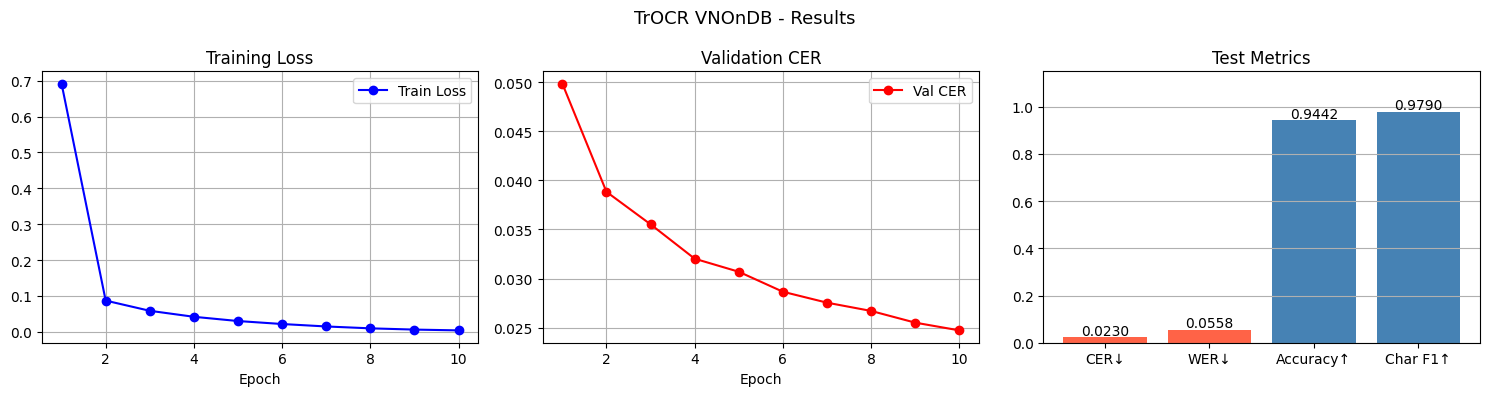


 Saved  /content/drive/MyDrive/Colab Notebooks/trocr_checkpoints/eval_results


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

hist = pd.read_csv(os.path.join(SAVE_DIR, 'train_history.csv'))
axes[0].plot(hist['epoch'], hist['train_loss'], 'b-o', label='Train Loss')
axes[0].set_title('Training Loss'); axes[0].set_xlabel('Epoch')
axes[0].legend(); axes[0].grid(True)

axes[1].plot(hist['epoch'], hist['val_cer'], 'r-o', label='Val CER')
axes[1].set_title('Validation CER'); axes[1].set_xlabel('Epoch')
axes[1].legend(); axes[1].grid(True)

names  = ['CER↓', 'WER↓', 'Accuracy↑', 'Char F1↑']
values = [cer_val, wer_val, accuracy, char_f1_val]
colors = ['tomato', 'tomato', 'steelblue', 'steelblue']
bars = axes[2].bar(names, values, color=colors)
for bar, val in zip(bars, values):
    axes[2].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                 f'{val:.4f}', ha='center', fontsize=10)
axes[2].set_ylim(0, 1.15); axes[2].set_title('Test Metrics'); axes[2].grid(axis='y')

plt.suptitle('TrOCR VNOnDB - Results', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(EVAL_DIR, 'results.png'), dpi=150)
plt.show()
print(f'\n Saved  {EVAL_DIR}')

# TEST TÙY CHỌN ẢNH TỪ MÁY

In [ ]:
!pip install -q easyocr
import os, io, torch, cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from google.colab import files
from PIL import Image
from transformers import TrOCRProcessor, VisionEncoderDecoderModel, GenerationConfig
import torch.nn as nn
import easyocr

DRIVE_BASE = '/content/drive/MyDrive/Colab Notebooks'
SAVE_DIR   = os.path.join(DRIVE_BASE, 'trocr_checkpoints')
device     = 'cuda' if torch.cuda.is_available() else 'cpu'



print(f'Device: {device}')
best_path = os.path.join(SAVE_DIR, 'best_model')

print('Loading TrOCR...')
processor = TrOCRProcessor.from_pretrained(best_path)
model     = VisionEncoderDecoderModel.from_pretrained(best_path).to(device)

model.eval()
print('  TrOCR loaded')

print('Loading EasyOCR detector...')
reader = easyocr.Reader(['vi'], recognizer=False, verbose=False)
print('  EasyOCR ready\n')

Device: cpu
Loading TrOCR...


Loading weights:   0%|          | 0/480 [00:00<?, ?it/s]

  TrOCR loaded
Loading EasyOCR detector...
  EasyOCR ready



Chọn ảnh từ máy...


Saving img1.jpg to img1 (2).jpg

Xử lý: img1 (2).jpg
  Tìm thấy 2 vùng chữ
    => "Hội"
    => "tụ"


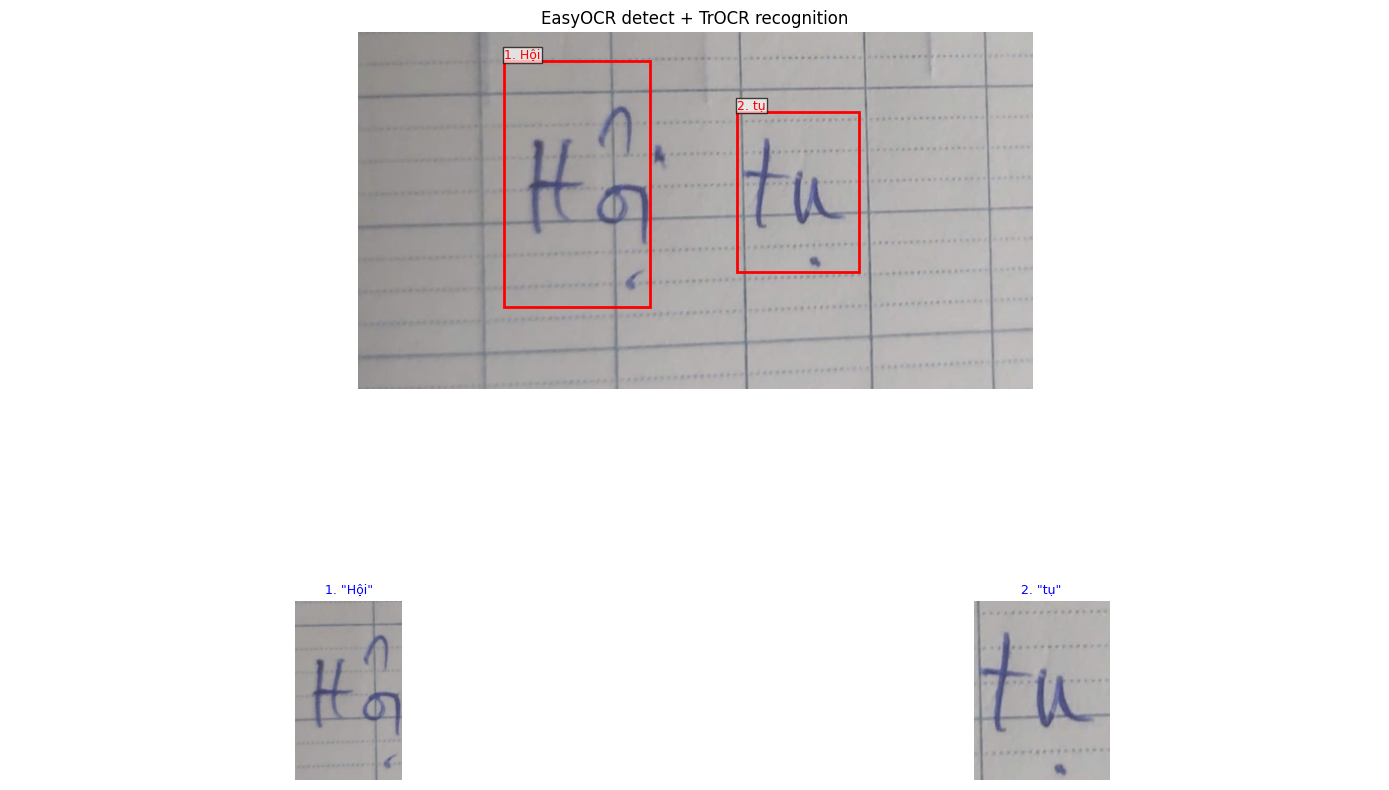


  Kết quả: "Hội tụ"


In [ ]:
demo_gen_cfg = GenerationConfig(
    max_new_tokens         = 32,
    num_beams              = 4,
    no_repeat_ngram_size   = 3,
    decoder_start_token_id = processor.tokenizer.cls_token_id,
    eos_token_id           = processor.tokenizer.sep_token_id,
    pad_token_id           = processor.tokenizer.pad_token_id,
)

def recognize_image(img_bytes):
    image        = Image.open(io.BytesIO(img_bytes)).convert('RGB')
    img_np       = np.array(image)
    h_img, w_img = img_np.shape[:2]

    bounds = reader.detect(img_np)
    boxes  = bounds[0][0] if bounds and bounds[0] else []

    if not boxes:
        print('  Không tìm thấy vùng chữ! Thử nhận dạng toàn ảnh...')
        pv = processor(image, return_tensors='pt').pixel_values.to(device)
        with torch.no_grad():
            ids  = model.generate(pv, generation_config=demo_gen_cfg)
            pred = processor.batch_decode(ids, skip_special_tokens=True)[0]
        plt.figure(figsize=(8, 4))
        plt.imshow(image); plt.axis('off')
        plt.title(f'Kết quả: "{pred}"', fontsize=13)
        plt.tight_layout(); plt.show()
        print(f'\n  Kết quả: {pred}')
        return pred

    print(f'  Tìm thấy {len(boxes)} vùng chữ')

    words = []
    for box in boxes:
        x1, x2, y1, y2 = int(box[0]), int(box[1]), int(box[2]), int(box[3])
        h   = y2 - y1
        cx1 = max(0,     x1 - 20)
        cx2 = min(w_img, x2 + 20)
        cy1 = max(0,     y1 - int(h * 0.6))
        cy2 = min(h_img, y2 + int(h * 0.6))
        crop = image.crop((cx1, cy1, cx2, cy2))
        pv   = processor(crop, return_tensors='pt').pixel_values.to(device)
        with torch.no_grad():
            ids  = model.generate(pv, generation_config=demo_gen_cfg)
            pred = processor.batch_decode(ids, skip_special_tokens=True)[0]
        words.append({'box': (cx1, cy1, cx2, cy2), 'pred': pred, 'crop': crop})
        print(f'    => "{pred}"')

    avg_h = np.mean([w['box'][3] - w['box'][1] for w in words])
    words.sort(key=lambda w: (int(w['box'][1] / (avg_h * 0.5)), w['box'][0]))

    n         = len(words)
    crop_cols = min(n, 6)
    crop_rows = (n + crop_cols - 1) // crop_cols

    fig, axes = plt.subplots(
        1 + crop_rows, max(crop_cols, 1),
        figsize=(max(14, crop_cols * 3), 5 + crop_rows * 3),
        gridspec_kw={'height_ratios': [3] + [1] * crop_rows}
    )
    if (1 + crop_rows) == 1: axes = axes.reshape(1, -1)
    if crop_cols == 1:       axes = axes.reshape(-1, 1)

    for ax in axes[0]: ax.axis('off')

    ax_main = fig.add_subplot(1 + crop_rows, 1, 1)
    ax_main.imshow(image)
    for i, w in enumerate(words):
        x1, y1, x2, y2 = w['box']
        ax_main.add_patch(patches.Rectangle(
            (x1, y1), x2-x1, y2-y1,
            linewidth=2, edgecolor='red', facecolor='none'
        ))
        ax_main.text(x1, y1-5, f'{i+1}. {w["pred"]}', color='red', fontsize=9,
                     bbox=dict(facecolor='white', alpha=0.7, pad=1))
    ax_main.set_title('EasyOCR detect + TrOCR recognition', fontsize=12)
    ax_main.axis('off')

    for i, w in enumerate(words):
        ax = axes[1 + i // crop_cols][i % crop_cols]
        ax.imshow(w['crop'])
        ax.set_title(f'{i+1}. "{w["pred"]}"', fontsize=9, color='blue')
        ax.axis('off')
    for i in range(n, crop_rows * crop_cols):
        axes[1 + i // crop_cols][i % crop_cols].axis('off')

    plt.tight_layout()
    plt.show()

    result = ' '.join(w['pred'] for w in words)
    print(f'\n  Kết quả: "{result}"')
    return result

print('Chọn ảnh từ máy...')
uploaded = files.upload()
for filename, data in uploaded.items():
    print(f'\nXử lý: {filename}')
    recognize_image(data)